# Frankenstein combination: CQSFA electron-2 saddle time plugged into the validated OrbitFinder amplitude

Builds on the validated pipeline in `Uniform_Approximation_Test.ipynb` (0.997 correlation with
OrbitFinder's native output), but:
1. Uses the **unsymmetrised quadrant** output directly (`%MS: 1 0 0 0` in
   `helium_resi_cross_quadrant.inp`) instead of reconstructing OrbitFinder's own L/R/U/D
   symmetrisation in Python - simpler and less error-prone.
2. Replaces electron 2's saddle time (`t3`, from OrbitFinder's own field-only SFA solve) with
   the Coulomb-corrected ionisation time `t0` actually found by `CQSFA_fwd`'s boundary-value
   solver, for the *same* laser field and $I_p=E_{2e}=0.5$ a.u., $Z=2$ (He$^+$) target.
3. Everything else (the uniform-approximation amplitude formula `getA`/`getMij_C`/`getMij_Q`,
   electron 1's own $t_1,t_2$) stays exactly as validated - per the user's guidance, we
   deliberately do **not** use CQSFA's own physical prefactor (Eq. 5.12 of the Eory report);
   we reuse OrbitFinder's SFA-style prefactor machinery with just the Coulomb-corrected time
   plugged in. This is an approximation - flagged clearly - not the full Frankenstein formula.
4. Symmetrise (L+R+U+D) the *final combined* Frankenstein amplitude at the end, not electron
   1's SFA-only piece in isolation.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.special import jv, kv
from scipy.interpolate import griddata

OrbitFinder_dir = "/workspaces/CQSFA/OrbitFinder/TestingSuite"
CQSFA_dir = "/workspaces/CQSFA/CQSFA_fwd/runs/Frankenstein_He_electron2_softened_1M"
GRID_TAG = "141X141"  # bumped again: step 0.1 -> 0.05, same actual range +/-4.32
NINITCOND_TAG = "1e+06"  # bumped 1000->10000->50000->1000000 (CQSFA_fwd prints NInitCond via %g)
GRID3D_TAG = "250X250X1"  # CQSFA_fwd's own Nz x Ny x Nx final-momentum grid (Amplitude_Grid file)
RUN_TAG = "softened_1M"  # aSoft=1.0, sigma=1.0 (further softened from H_800_1e14's aSoft=1e-6, sigma=0.5) - reduces rescattering

omega = 0.057
Up = 0.6579
Up0 = Up / omega

Ip1, Ip2, Ip12 = 0.97, 2.0, 0.5  # I1g, I2g, I2e (Helium RESI channel)
BUMP = 1e-4

## Validated building blocks (copied from `Uniform_Approximation_Test.ipynb`)

In [8]:
def f12(e1_long, e1_trans, t1, t2):
    p10 = e1_long * np.sqrt(Up0)
    p1tr0 = e1_trans * np.sqrt(Up0)
    ip10, ip120, ip20 = Ip1 / omega, Ip12 / omega, Ip2 / omega
    sin_t1, sin_2t1, sin_t2 = np.sin(t1), np.sin(2 * t1), np.sin(t2)
    X = (sin_t2 - sin_t1) ** 2 / (t2 - t1)
    return (
        t1 * (Up0 + ip10)
        + t2 * (ip20 - ip120 + 0.5 * (p10 ** 2 + p1tr0 ** 2))
        + sin_2t1 * 0.5 * Up0 + sin_t2 * 2 * p10 * np.sqrt(Up0) + X * 2 * Up0
    )


def f3(e2_long, e2_trans, t3):
    p20 = e2_long * np.sqrt(Up0)
    p2tr0 = e2_trans * np.sqrt(Up0)
    ip120 = Ip12 / omega
    return (
        t3 * (0.5 * (p20 ** 2 + p2tr0 ** 2) + Up0 + ip120)
        + np.sin(t3) * p20 * np.sqrt(4 * Up0) + np.sin(2 * t3) * 0.5 * Up0
    )


def hessian_f12(e1_long, e1_trans, t1, t2):
    S = lambda a, b: f12(e1_long, e1_trans, a, b)
    d11 = (S(t1 + BUMP, t2) - 2 * S(t1, t2) + S(t1 - BUMP, t2)) / BUMP ** 2
    d22 = (S(t1, t2 + BUMP) - 2 * S(t1, t2) + S(t1, t2 - BUMP)) / BUMP ** 2
    d12 = (S(t1 + BUMP, t2 + BUMP) - S(t1 + BUMP, t2 - BUMP) - S(t1 - BUMP, t2 + BUMP) + S(t1 - BUMP, t2 - BUMP)) / (4 * BUMP ** 2)
    return d11, d22, d12


def d33_f3(e2_long, e2_trans, t3):
    S = lambda a: f3(e2_long, e2_trans, a)
    return (S(t3 + BUMP) - 2 * S(t3) + S(t3 - BUMP)) / BUMP ** 2


def getA(diff, d33, t1, t2):
    factor = (2 * np.pi) ** 3
    ts3 = (np.sqrt(1j * (t1 - t2))) ** 3
    temp = np.sqrt(-diff) * np.sqrt(-1j * d33) * ts3
    return factor / temp


def getdS(X, Y): return 0.5 * (X - Y)
def getdA(X, Y): return 0.5 * (X - 1j * Y)
def getSbar(X, Y): return 0.5 * (X + Y)
def getAbar(X, Y): return 0.5 * (1j * X - Y)


def getMij_C(a1, a2, A1, A2):
    dS, dA, Sbar, Abar = getdS(a1, a2), getdA(A1, A2), getSbar(a1, a2), getAbar(A1, A2)
    Rcomp = np.sqrt(2 * np.pi / 3 * dS)
    expS = np.exp(1j * (Sbar + np.pi / 4))
    Bsum = (jv(1 / 3, dS) + jv(-1 / 3, dS)) * dA + (jv(2 / 3, dS) - jv(-2 / 3, dS)) * Abar
    return expS * Bsum * Rcomp


def getMij_Q(a1, a2, A1, A2):
    dS, dA, Sbar, Abar = getdS(a1, a2), getdA(A1, A2), getSbar(a1, a2), getAbar(A1, A2)
    Darg = 1j * dS
    Rcomp = np.sqrt(2 / np.pi * Darg)
    expS = np.exp(1j * Sbar)
    Darg2 = -Darg
    Lpart = Abar * kv(1 / 3, Darg2)
    Rpart = 1j * dA * kv(2 / 3, Darg2)
    return expS * (Lpart + Rpart) * Rcomp

## Electron 1: OrbitFinder's own $t_1,t_2$ (unchanged, from the quadrant run)

In [9]:
def load_orbit(fname):
    rows = np.loadtxt(fname)
    pl, pt = rows[:, 0], rows[:, 1]
    t1 = rows[:, 2] + 1j * rows[:, 3]
    t2 = rows[:, 4] + 1j * rows[:, 5]
    t3 = rows[:, 6] + 1j * rows[:, 7]
    long_axis = np.unique(np.round(pl, 3))
    trans_axis = np.unique(np.round(pt, 3))
    n = len(long_axis)

    def to_grid(vals):
        g = np.full((n, n), np.nan, dtype=vals.dtype)
        i_idx = np.searchsorted(long_axis, np.round(pl, 3))
        j_idx = np.searchsorted(trans_axis, np.round(pt, 3))
        g[i_idx, j_idx] = vals
        return g

    return long_axis, trans_axis, to_grid(t1), to_grid(t2), to_grid(t3)


pax, tax, T1S, T2S, T3S = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.shortorbit")
_, _, T1L, T2L, T3L = load_orbit(f"{OrbitFinder_dir}/results/helium_resi_cross_quadrant.inp_Range_{GRID_TAG}_channel:0.longorbit")
n = len(pax)
hsize = int(np.floor(n / 2.0 + 0.5))  # C++ std::round (round-half-away-from-zero), not Python's banker's round
tax_half = pax[:hsize]
print(f"grid {n}x{n}, hsize={hsize}, p_trans (half) in [{tax_half.min():.3f},{tax_half.max():.3f}]")

grid 141x141, hsize=71, p_trans (half) in [-4.315,0.000]


## Electron 2: CQSFA_fwd's $t_0$ (orbit 1) instead of OrbitFinder's own $t_3$

`CQSFA_fwd`'s `Binned_Initial_Condition_Grid` file gives scattered `(pf_z, pf_perp, t0)` points
per orbit type. We take orbit 1 (the most direct trajectory) and interpolate its $t_0$ onto the
$(p_{2,long}, p_{2,trans}\le0)$ grid needed here.

In [10]:
cqsfa_data = np.loadtxt(f"{CQSFA_dir}/Data/Binned_Initial_Condition_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
orbit = cqsfa_data[:, 9].astype(int)
pf_z, pf_perp = cqsfa_data[:, 6], cqsfa_data[:, 7]
# CQSFA_fwd's t0 is an ABSOLUTE time in a.u.; OrbitFinder's t1,t2,t3 are field PHASES (omega*t).
# Confirmed by magnitude: t0~76 a.u. * omega(0.057) = 4.3, right in OrbitFinder's t1/t2/t3 range
# (~2-6.5), whereas the raw t0 values (~34-90) are far outside that range on their own.
t0 = omega * (cqsfa_data[:, 3] + 1j * cqsfa_data[:, 4])

mask = orbit == 1
print(f"orbit 1: {mask.sum()} points, pf_z in [{pf_z[mask].min():.2f},{pf_z[mask].max():.2f}], "
      f"pf_perp in [{pf_perp[mask].min():.2f},{pf_perp[mask].max():.2f}]")
print(f"phase-converted t0 sample: {t0[mask][:3]}")

# Interpolate (real & imaginary parts separately) onto the (p2long, p2trans<=0) grid needed.
# Restrict p2long to CQSFA's actual data coverage to avoid extrapolation artefacts.
p2long_axis = pax[np.abs(pax) <= np.abs(pf_z[mask]).max()]
p2trans_axis = tax_half[np.abs(tax_half) <= np.abs(pf_perp[mask]).max()]
P2L, P2T = np.meshgrid(p2long_axis, p2trans_axis, indexing="ij")

t0_re_grid = griddata((pf_z[mask], pf_perp[mask]), t0[mask].real, (P2L, P2T), method="linear")
t0_im_grid = griddata((pf_z[mask], pf_perp[mask]), t0[mask].imag, (P2L, P2T), method="linear")
T0_CQSFA = t0_re_grid + 1j * t0_im_grid

print(f"interpolated grid: {T0_CQSFA.shape}, valid (non-nan) fraction = {np.isfinite(T0_CQSFA).mean():.2f}")
print(f"p2long range used: [{p2long_axis.min():.3f},{p2long_axis.max():.3f}], "
      f"p2trans range used: [{p2trans_axis.min():.3f},{p2trans_axis.max():.3f}]")

orbit 1: 14477 points, pf_z in [-2.65,2.65], pf_perp in [-1.34,1.34]
phase-converted t0 sample: [0.46427409+1.17694736j 0.45999393+1.17493855j 4.33577581+0.92671222j]
interpolated grid: (87, 22), valid (non-nan) fraction = 0.83
p2long range used: [-2.651,2.651], p2trans range used: [-1.295,0.000]


## Combine: electron 1 (OrbitFinder SFA, unchanged) x electron 2 (CQSFA time plugged into the same amplitude formula)

For each (p1long, p2long, p1trans, p2trans) point, keep electron 1's own short/long uniform
approximation exactly as validated, but replace $t_3$ (and the $d_{33}$ built from it) with the
CQSFA-derived $t_0$ at the matching $(p2long, p2trans)$ point. Points where CQSFA's orbit-1 data
doesn't cover (interpolation gave NaN) are set to zero contribution.

In [11]:
import time

n1_long = n            # 29, electron 1's p_long (full)
n1_trans = hsize        # 15, electron 1's p_trans (half, <=0)
n2_long = len(p2long_axis)
n2_trans = len(p2trans_axis)

valid2 = np.isfinite(T0_CQSFA)  # [n2_long, n2_trans]

W4c = np.zeros((n1_long, n2_long, n1_trans, n2_trans))

t0_start = time.time()
for i in range(n1_long):
    s12_short_row = f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
    s12_long_row = f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
    d11s_r, d22s_r, d12s_r = hessian_f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
    d11l_r, d22l_r, d12l_r = hessian_f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
    diff_s_row = d11s_r * d22s_r - d12s_r ** 2
    diff_l_row = d11l_r * d22l_r - d12l_r ** 2
    stoke_row = (s12_short_row - s12_long_row).real > 0

    for j in range(n2_long):
        t0_col = T0_CQSFA[j, :]           # CQSFA electron-2 time, replaces t3
        s3_col = f3(p2long_axis[j], p2trans_axis, t0_col)
        d33_col = d33_f3(p2long_axis[j], p2trans_axis, t0_col)
        valid_col = valid2[j, :]

        for ii in range(n1_trans):
            Along_vec = getA(diff_l_row[ii], d33_col, T1L[i, ii], T2L[i, ii])
            Ashort_vec = getA(diff_s_row[ii], d33_col, T1S[i, ii], T2S[i, ii])
            action_short = s12_short_row[ii] + s3_col
            action_long = s12_long_row[ii] + s3_col

            if stoke_row[ii]:
                Mij_row = getMij_C(action_short, action_long, Ashort_vec, Along_vec)
            else:
                Mij_row = getMij_Q(action_long, action_short, Along_vec, Ashort_vec)

            Mij_row = np.where(valid_col, Mij_row, 0.0)
            W4c[i, j, ii, :] = np.abs(Mij_row) ** 2

print("elapsed:", time.time() - t0_start)
print("W4c stats: min", W4c.min(), "max", W4c.max(), "nan:", np.isnan(W4c).sum())

/tmp/ipykernel_255299/186387296.py:41: RuntimeWarning: invalid value encountered in divide
  return factor / temp


elapsed: 42.603628635406494
W4c stats: min 0.0 max 3.7322773033103725e-13 nan: 0


cleaned 0 nan and 0 inf points -> 0
W4c_clean max: 3.7322773033103725e-13


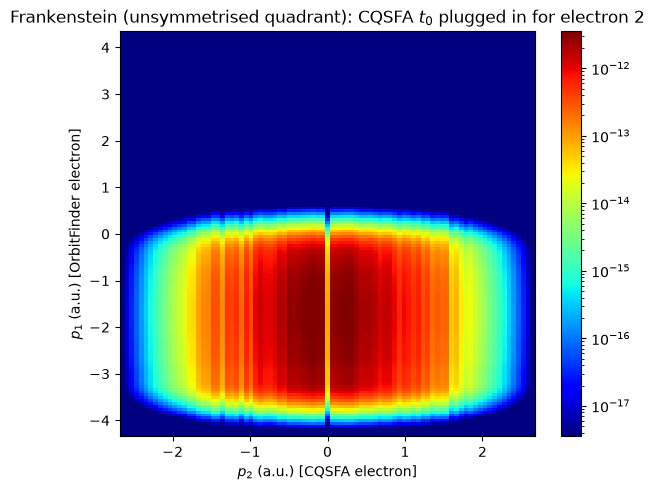

In [12]:
# Clean up NaN/inf (from overflow at points where the interpolated CQSFA time gives an
# extreme/unphysical action - same treatment as the earlier masking of divergent branches).
W4c_clean = np.nan_to_num(W4c, nan=0.0, posinf=0.0, neginf=0.0)
print(f"cleaned {np.isnan(W4c).sum()} nan and {np.isinf(W4c).sum()} inf points -> 0")
print("W4c_clean max:", W4c_clean.max())

# Compare against electron-1-only "quadrant" reference for the SAME (p1long,p1trans) sub-grid,
# just to see how much the CQSFA electron-2 substitution changes the picture in the region
# where CQSFA data is available. Sum over trans axes with the p_trans Jacobian weighting.
p1trans_w = tax_half[None, None, :, None]
p2trans_w = p2trans_axis[None, None, None, :]
prob_frankenstein = (W4c_clean * p1trans_w * p2trans_w).sum(axis=(2, 3))  # [p1long, p2long]

fig, ax = plt.subplots(figsize=(6, 5))
d = np.abs(prob_frankenstein)
mask = d > 0
vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
pcm = ax.pcolormesh(p2long_axis, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA electron]")
ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
ax.set_title("Frankenstein (unsymmetrised quadrant): CQSFA $t_0$ plugged in for electron 2")
fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

## Compare against plain SFA (OrbitFinder's own $t_3$, no Coulomb correction)

Rebuild the same combination, but using OrbitFinder's own long-branch $t_3$ (over the identical
restricted $(p_2long, p_2trans)$ sub-grid) instead of CQSFA's $t_0$ - an apples-to-apples "with
vs without Coulomb correction" comparison.

In [13]:
import time

# Find the exact indices in the full (pax, tax_half) grid matching p2long_axis/p2trans_axis,
# so we read OrbitFinder's own t3 (long branch) on the identical sub-grid used for CQSFA above.
long_idx = np.searchsorted(pax, p2long_axis)
trans_idx = np.searchsorted(tax_half, p2trans_axis)
T3_SFA = T3L[np.ix_(long_idx, trans_idx)]  # [n2_long, n2_trans], OrbitFinder's own electron-2 time

W4_sfa = np.zeros((n1_long, n2_long, n1_trans, n2_trans))

t0_start = time.time()
for i in range(n1_long):
    s12_short_row = f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
    s12_long_row = f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
    d11s_r, d22s_r, d12s_r = hessian_f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
    d11l_r, d22l_r, d12l_r = hessian_f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
    diff_s_row = d11s_r * d22s_r - d12s_r ** 2
    diff_l_row = d11l_r * d22l_r - d12l_r ** 2
    stoke_row = (s12_short_row - s12_long_row).real > 0

    for j in range(n2_long):
        t3_col = T3_SFA[j, :]
        s3_col = f3(p2long_axis[j], p2trans_axis, t3_col)
        d33_col = d33_f3(p2long_axis[j], p2trans_axis, t3_col)

        for ii in range(n1_trans):
            Along_vec = getA(diff_l_row[ii], d33_col, T1L[i, ii], T2L[i, ii])
            Ashort_vec = getA(diff_s_row[ii], d33_col, T1S[i, ii], T2S[i, ii])
            action_short = s12_short_row[ii] + s3_col
            action_long = s12_long_row[ii] + s3_col

            if stoke_row[ii]:
                Mij_row = getMij_C(action_short, action_long, Ashort_vec, Along_vec)
            else:
                Mij_row = getMij_Q(action_long, action_short, Along_vec, Ashort_vec)

            W4_sfa[i, j, ii, :] = np.abs(Mij_row) ** 2

print("elapsed:", time.time() - t0_start)
W4_sfa_clean = np.nan_to_num(W4_sfa, nan=0.0, posinf=0.0, neginf=0.0)
prob_sfa = (W4_sfa_clean * p1trans_w * p2trans_w).sum(axis=(2, 3))
print("prob_sfa max:", np.abs(prob_sfa).max())

elapsed: 47.45451641082764
prob_sfa max: 4.529860758146405e-12


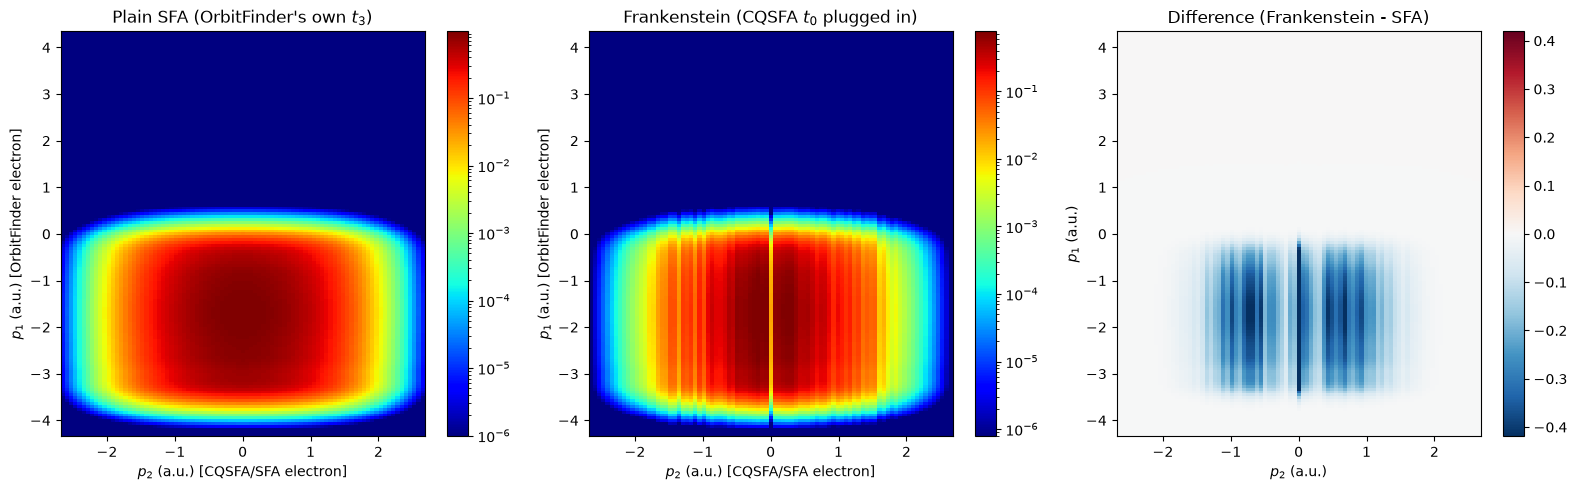

max|difference| = 98.0% of the SFA peak
raw amplitude scale ratio (Frankenstein/SFA, unnormalised) = 0.8885


In [14]:
# Side-by-side comparison, same colour scale (shared normalisation by the SFA peak, since both
# now go through the identical amplitude formula - only the electron-2 saddle time differs).
shared_norm = np.abs(prob_sfa).max()
prob_sfa_n = np.abs(prob_sfa) / shared_norm
prob_fr_n = np.abs(prob_frankenstein) / shared_norm
diff = prob_fr_n - prob_sfa_n

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, d, title in [
    (axes[0], prob_sfa_n, "Plain SFA (OrbitFinder's own $t_3$)"),
    (axes[1], prob_fr_n, "Frankenstein (CQSFA $t_0$ plugged in)"),
]:
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(p2long_axis, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
    ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

vmax_d = np.percentile(np.abs(diff), 99.5)
pcm3 = axes[2].pcolormesh(p2long_axis, pax, diff, vmin=-vmax_d, vmax=vmax_d, shading="auto", cmap="RdBu_r")
axes[2].set_xlabel(r"$p_{2}$ (a.u.)"); axes[2].set_ylabel(r"$p_{1}$ (a.u.)")
axes[2].set_title("Difference (Frankenstein - SFA)")
fig.colorbar(pcm3, ax=axes[2])
plt.tight_layout()
plt.show()

print(f"max|difference| = {np.abs(diff).max()*100:.1f}% of the SFA peak")
print(f"raw amplitude scale ratio (Frankenstein/SFA, unnormalised) = {np.abs(prob_frankenstein).max()/np.abs(prob_sfa).max():.4f}")

## All four CQSFA orbits, separately and coherently combined

`CQSFA_fwd` classifies each solved trajectory into one of 4 orbit types. So far we only used
orbit 1. Now: interpolate each orbit's $t_0$ onto the **full** electron-2 grid (same shape as
electron 1's, `pax` x `tax_half`), build the Frankenstein amplitude for each orbit separately
(keeping it complex, not yet squared), then **coherently sum the 4 complex amplitudes** at each
grid point (like different saddle-point branches contributing to the same final momentum) before
squaring - this is the physically correct way to combine multiple trajectories in the SFA/CQSFA
formalism, not summing probabilities.

In [15]:
# Interpolate each orbit's t0 onto the FULL (pax, tax_half) grid - same shape as electron 1 -
# so the four orbits (and the SFA baseline) all live on identical grids and can be combined/compared directly.
P2L_full, P2T_full = np.meshgrid(pax, tax_half, indexing="ij")  # shape (n, hsize)

T0_orbits = {}
valid_orbits = {}
for k in (1, 2, 3, 4):
    m = orbit == k
    re_grid = griddata((pf_z[m], pf_perp[m]), t0[m].real, (P2L_full, P2T_full), method="linear")
    im_grid = griddata((pf_z[m], pf_perp[m]), t0[m].imag, (P2L_full, P2T_full), method="linear")
    T0_orbits[k] = re_grid + 1j * im_grid
    valid_orbits[k] = np.isfinite(T0_orbits[k])
    print(f"orbit {k}: {m.sum():6d} points, pf_z in [{pf_z[m].min():.2f},{pf_z[m].max():.2f}], "
          f"pf_perp in [{pf_perp[m].min():.2f},{pf_perp[m].max():.2f}], "
          f"grid coverage = {valid_orbits[k].mean():.2f}")

orbit 1:  14477 points, pf_z in [-2.65,2.65], pf_perp in [-1.34,1.34], grid coverage = 0.16
orbit 2:  16195 points, pf_z in [-2.62,2.62], pf_perp in [-1.34,1.34], grid coverage = 0.15
orbit 3:  16306 points, pf_z in [-2.65,2.65], pf_perp in [-0.85,0.95], grid coverage = 0.10
orbit 4:   4380 points, pf_z in [-1.86,1.86], pf_perp in [-0.95,0.99], grid coverage = 0.08


## Diagnostic: CQSFA electron 2 alone (no combination with electron 1)

Before combining with electron 1, look directly at what CQSFA computes for electron 2 by
itself, using its OWN genuine (Coulomb-corrected) action and prefactor - not the Python
reuse of OrbitFinder's SFA action formula used elsewhere in this notebook.

1. `Amplitude_Grid_*.dat` is CQSFA_fwd's own regular (Nz x Ny) final-momentum grid, with the
   coherent sum over all 4 orbits already baked in - column `Ppref` is the genuine physical
   (prefactor-weighted) electron-2-only probability map.
2. To see the asymmetry per orbit (each orbit = a different tunnelling-exit trajectory
   topology, see `orbTypes`/orbit classification in the C++ code), reconstruct
   `Mpref = prefactor * exp(i*Stotal)` point-by-point from the scattered
   `Binned_Initial_Condition_Grid` (orbit label), `Action_Grid` (Stotal components) and
   `Prefactor_Grid` (prefactor) files - confirmed to be in the same row order/count - then
   split by orbit.

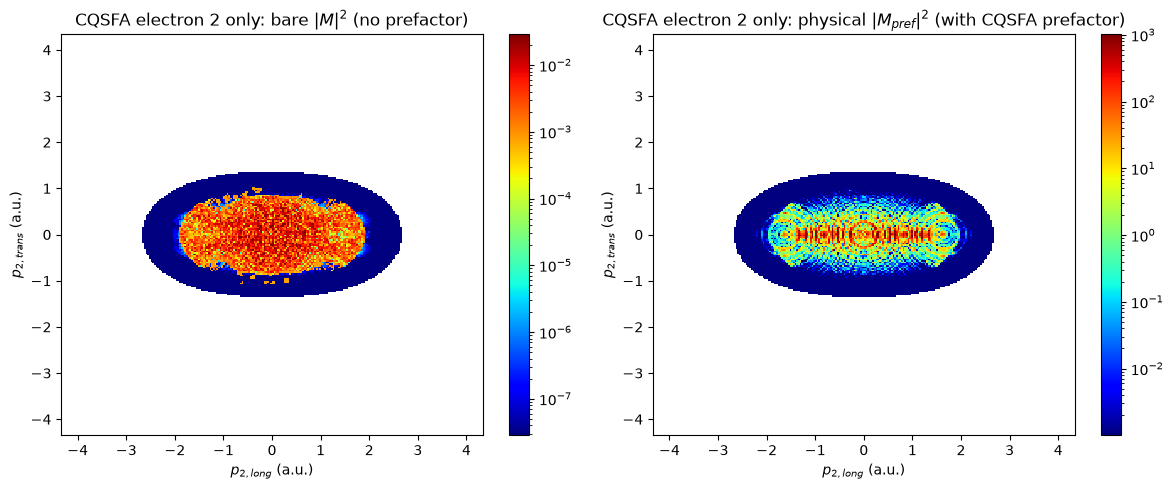

In [16]:
# CQSFA-only, all-orbits-combined electron-2 map: native Amplitude_Grid, already a regular
# (Nz x Ny) grid with the coherent sum over all 4 orbits and the real CQSFA prefactor baked in.
amp_data = np.loadtxt(f"{CQSFA_dir}/Data/Amplitude_Grid_Frankenstein_He_electron2_{RUN_TAG}_{GRID3D_TAG}.dat")
Nz = Ny = 250
amp_pf_z = amp_data[:, 0].reshape(Nz, Ny)
amp_pf_perp = amp_data[:, 1].reshape(Nz, Ny)
amp_Ppref = amp_data[:, 8].reshape(Nz, Ny)  # |Mpref|^2, physical (prefactor-weighted) probability

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (data, title) in zip(axes, [(amp_data[:, 5].reshape(Nz, Ny), "bare $|M|^2$ (no prefactor)"),
                                     (amp_Ppref, "physical $|M_{pref}|^2$ (with CQSFA prefactor)")]):
    d = np.abs(data)
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(amp_pf_z[:, 0], amp_pf_perp[0, :], d.T, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2,long}$ (a.u.)"); ax.set_ylabel(r"$p_{2,trans}$ (a.u.)")
    ax.set_title(f"CQSFA electron 2 only: {title}")
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

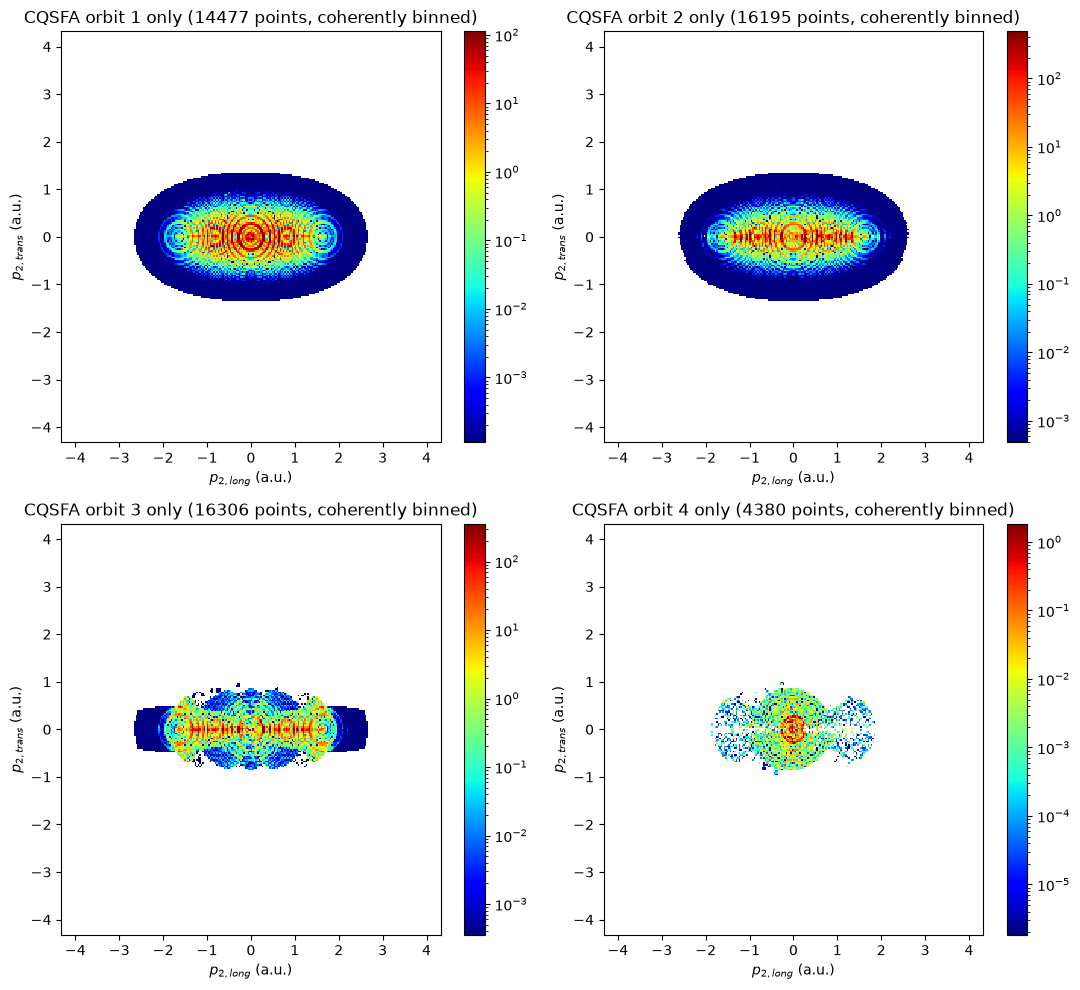

In [17]:
# Per-orbit CQSFA-only amplitude: reconstruct Mpref = prefactor * exp(i*Stotal) point-by-point
# from the scattered per-trajectory files (all confirmed same row order/count).
binned = np.loadtxt(f"{CQSFA_dir}/Data/Binned_Initial_Condition_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
action = np.loadtxt(f"{CQSFA_dir}/Data/Action_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")
prefac = np.loadtxt(f"{CQSFA_dir}/Data/Prefactor_Grid_Frankenstein_He_electron2_{RUN_TAG}_{NINITCOND_TAG}.dat")

orbit_pt = binned[:, 9].astype(int)
pf_z_pt, pf_perp_pt = action[:, 0], action[:, 1]

# Stotal = St + Sp0 + Sv0 + Sp + Sv (Sso NOT included - disabled in ActionData.cpp). Sp has no imag part.
Stotal_re = action[:, 3] + action[:, 5] + action[:, 7] + action[:, 9] + action[:, 10]
Stotal_im = action[:, 4] + action[:, 6] + action[:, 8] + action[:, 11]
Stotal = Stotal_re + 1j * Stotal_im
prefactor_pt = prefac[:, 3] + 1j * prefac[:, 4]
Mpref_pt = prefactor_pt * np.exp(1j * Stotal)

# IMPORTANT: bin coherently onto a regular grid (matching what CQSFA_fwd's own Amplitude_Grid
# does internally - sum COMPLEX amplitudes of every trajectory landing in the same target bin,
# THEN take |.|^2) rather than a raw scatter plot of individual points. An unordered scatter of
# ~10-60k overlapping points, drawn in file order with a small marker size and log colour scale,
# can produce spurious ring/Moire-like patterns purely from matplotlib's draw order - NOT real
# interference. Binning first avoids that rendering artifact entirely.
Nb = 250
edges = np.linspace(-4.32, 4.32, Nb + 1)
centers = 0.5 * (edges[:-1] + edges[1:])

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for k, ax in zip((1, 2, 3, 4), axes.flat):
    m = orbit_pt == k
    iz = np.clip(np.searchsorted(edges, pf_z_pt[m], side="right") - 1, 0, Nb - 1)
    ip = np.clip(np.searchsorted(edges, pf_perp_pt[m], side="right") - 1, 0, Nb - 1)
    Mgrid = np.zeros((Nb, Nb), dtype=complex)
    np.add.at(Mgrid, (iz, ip), Mpref_pt[m])  # coherent complex sum per bin
    d = np.abs(Mgrid) ** 2
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(centers, centers, d.T, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2,long}$ (a.u.)"); ax.set_ylabel(r"$p_{2,trans}$ (a.u.)")
    ax.set_title(f"CQSFA orbit {k} only ({m.sum()} points, coherently binned)")
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

In [18]:
import time

# Electron 1's short/long quantities depend only on OrbitFinder's own grid - compute once,
# reuse for every orbit (and the SFA baseline) instead of recomputing 5x.
S12_SHORT = np.zeros((n, hsize), dtype=complex)
S12_LONG = np.zeros((n, hsize), dtype=complex)
DIFF_SHORT = np.zeros((n, hsize), dtype=complex)
DIFF_LONG = np.zeros((n, hsize), dtype=complex)
STOKE = np.zeros((n, hsize), dtype=bool)

for i in range(n):
    S12_SHORT[i] = f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
    S12_LONG[i] = f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
    d11s_r, d22s_r, d12s_r = hessian_f12(pax[i], tax_half, T1S[i, :hsize], T2S[i, :hsize])
    d11l_r, d22l_r, d12l_r = hessian_f12(pax[i], tax_half, T1L[i, :hsize], T2L[i, :hsize])
    DIFF_SHORT[i] = d11s_r * d22s_r - d12s_r ** 2
    DIFF_LONG[i] = d11l_r * d22l_r - d12l_r ** 2
    STOKE[i] = (S12_SHORT[i] - S12_LONG[i]).real > 0


def compute_M(T0_grid, valid_grid):
    """Complex Frankenstein amplitude (electron 1 short/long uniform approx x electron 2's
    t0_grid), shape (n1_long=n, n2_long=n, n1_trans=hsize, n2_trans=hsize). Invalid (uncovered)
    electron-2 points contribute exactly 0."""
    M = np.zeros((n, n, hsize, hsize), dtype=complex)
    for j in range(n):
        t0_col = T0_grid[j, :]
        s3_col = f3(pax[j], tax_half, t0_col)
        d33_col = d33_f3(pax[j], tax_half, t0_col)
        valid_col = valid_grid[j, :]
        for i in range(n):
            for ii in range(hsize):
                Along_vec = getA(DIFF_LONG[i, ii], d33_col, T1L[i, ii], T2L[i, ii])
                Ashort_vec = getA(DIFF_SHORT[i, ii], d33_col, T1S[i, ii], T2S[i, ii])
                action_short = S12_SHORT[i, ii] + s3_col
                action_long = S12_LONG[i, ii] + s3_col
                if STOKE[i, ii]:
                    Mij_row = getMij_C(action_short, action_long, Ashort_vec, Along_vec)
                else:
                    Mij_row = getMij_Q(action_long, action_short, Along_vec, Ashort_vec)
                M[i, j, ii, :] = np.where(valid_col, Mij_row, 0.0)
    return M


t_start = time.time()
M_orbits = {k: compute_M(T0_orbits[k], valid_orbits[k]) for k in (1, 2, 3, 4)}
print("elapsed for 4 orbits:", time.time() - t_start)
for k in (1, 2, 3, 4):
    print(f"orbit {k}: |M| max = {np.abs(M_orbits[k]).max():.3e}")

/tmp/ipykernel_255299/186387296.py:41: RuntimeWarning: invalid value encountered in divide
  return factor / temp


elapsed for 4 orbits: 267.21076917648315
orbit 1: |M| max = 6.109e-07
orbit 2: |M| max = 6.139e-07
orbit 3: |M| max = 6.099e-07
orbit 4: |M| max = 6.161e-07


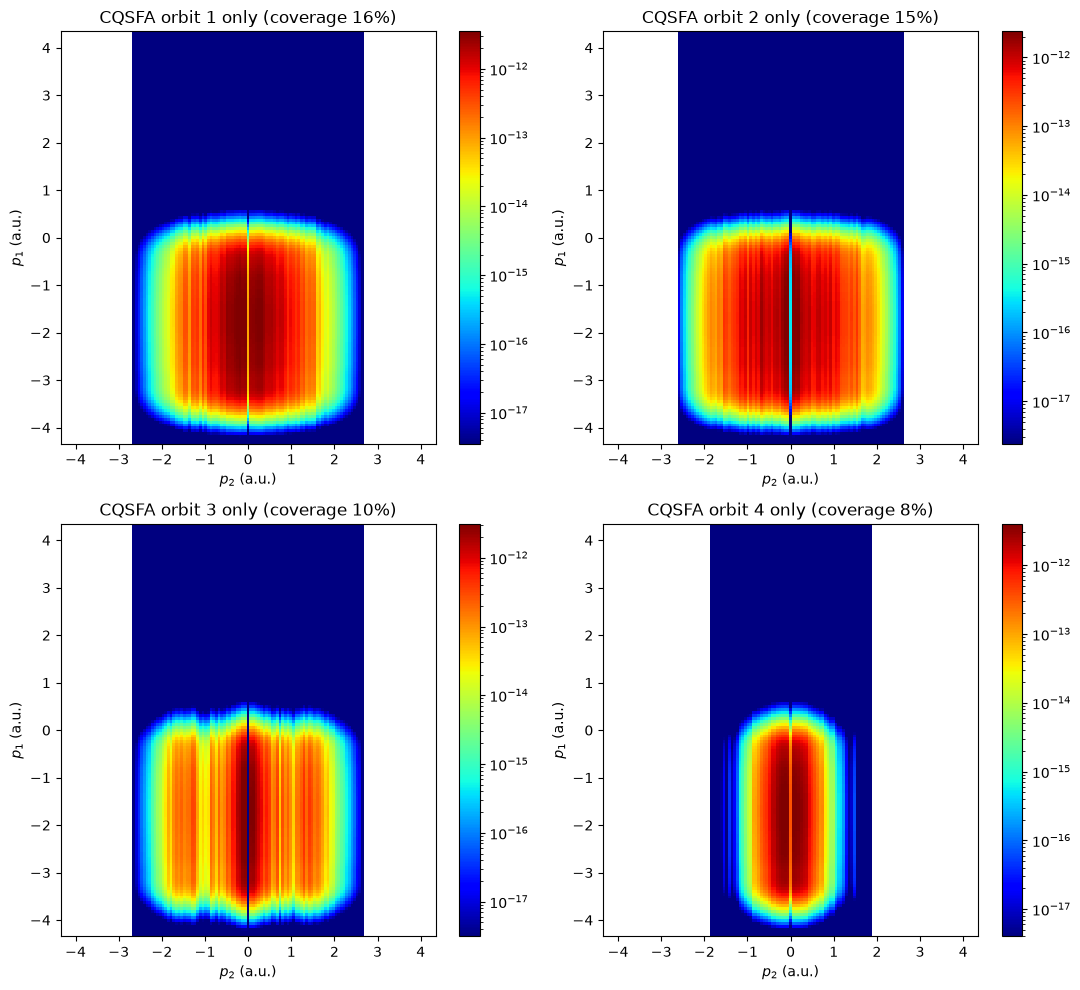

In [19]:
p1trans_w_full = tax_half[None, None, :, None]
p2trans_w_full = tax_half[None, None, None, :]

prob_orbits = {}
for k in (1, 2, 3, 4):
    Wk = np.abs(M_orbits[k]) ** 2
    prob_orbits[k] = (Wk * p1trans_w_full * p2trans_w_full).sum(axis=(2, 3))

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for k, ax in zip((1, 2, 3, 4), axes.flat):
    d = np.abs(prob_orbits[k])
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.)"); ax.set_ylabel(r"$p_{1}$ (a.u.)")
    ax.set_title(f"CQSFA orbit {k} only (coverage {valid_orbits[k].mean():.0%})")
    fig.colorbar(pcm, ax=ax)
plt.tight_layout()
plt.show()

In [20]:
# Coherently combine the 4 orbits (sum complex amplitudes, THEN square) - each orbit is a
# distinct saddle-point trajectory contributing to the same final momentum, exactly like
# electron 1's own short/long branches.
M_combined = sum(M_orbits[k] for k in (1, 2, 3, 4))
W_combined = np.abs(M_combined) ** 2
prob_combined = (W_combined * p1trans_w_full * p2trans_w_full).sum(axis=(2, 3))

# Full-grid SFA baseline (OrbitFinder's own t3, no Coulomb correction) for the same comparison,
# reusing the same compute_M machinery - T3L is already on the identical (pax, tax_half) grid.
T0_sfa_full = T3L[:, :hsize]
valid_sfa_full = np.ones_like(T0_sfa_full, dtype=bool)
M_sfa_full = compute_M(T0_sfa_full, valid_sfa_full)
W_sfa_full = np.abs(M_sfa_full) ** 2
prob_sfa_full = (W_sfa_full * p1trans_w_full * p2trans_w_full).sum(axis=(2, 3))

print(f"combined (orbits 1-4) max = {np.abs(prob_combined).max():.3e}")
print(f"SFA (full grid) max       = {np.abs(prob_sfa_full).max():.3e}")
print(f"ratio combined/SFA        = {np.abs(prob_combined).max()/np.abs(prob_sfa_full).max():.4f}")

KeyboardInterrupt: 

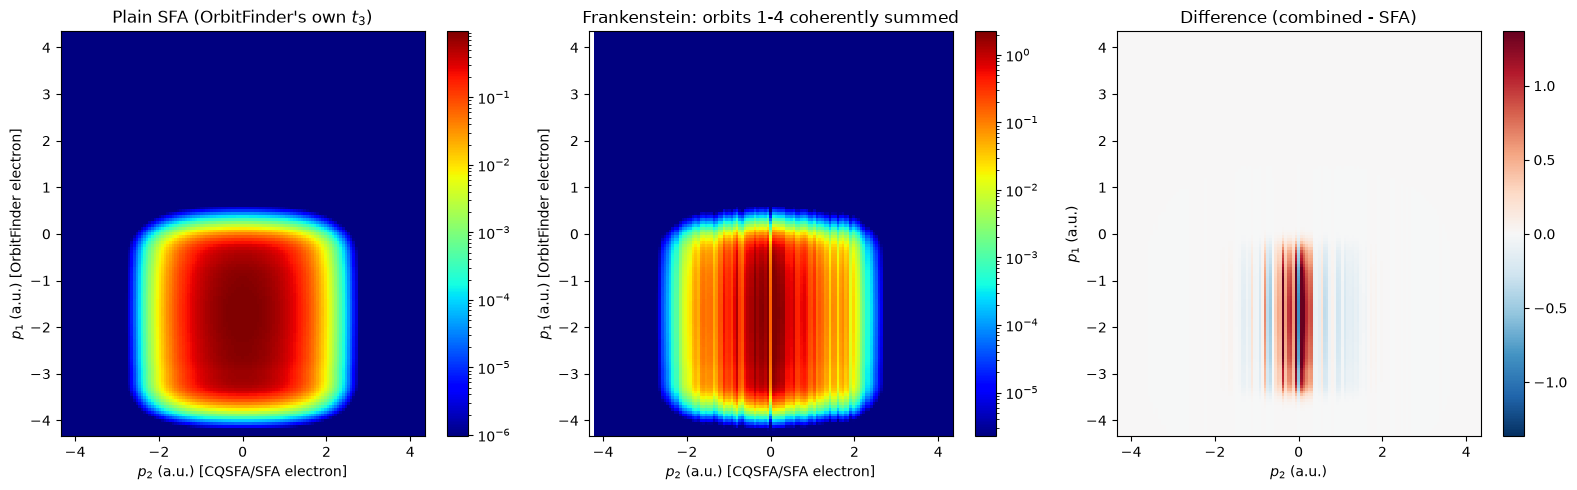

raw amplitude scale ratio (combined/SFA, unnormalised) = 2.8066


: 

In [ ]:
shared_norm2 = np.abs(prob_sfa_full).max()
d_sfa = np.abs(prob_sfa_full) / shared_norm2
d_comb = np.abs(prob_combined) / shared_norm2

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, d, title in [
    (axes[0], d_sfa, "Plain SFA (OrbitFinder's own $t_3$)"),
    (axes[1], d_comb, "Frankenstein: orbits 1-4 coherently summed"),
]:
    mask = d > 0
    vmax = np.percentile(d[mask], 99.5) if mask.any() else 1.0
    pcm = ax.pcolormesh(pax, pax, d, norm=LogNorm(vmin=vmax * 1e-6, vmax=vmax), shading="auto", cmap="jet")
    ax.set_xlabel(r"$p_{2}$ (a.u.) [CQSFA/SFA electron]")
    ax.set_ylabel(r"$p_{1}$ (a.u.) [OrbitFinder electron]")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax)

diff2 = d_comb - d_sfa
vmax_d2 = np.percentile(np.abs(diff2), 99.5)
pcm3 = axes[2].pcolormesh(pax, pax, diff2, vmin=-vmax_d2, vmax=vmax_d2, shading="auto", cmap="RdBu_r")
axes[2].set_xlabel(r"$p_{2}$ (a.u.)"); axes[2].set_ylabel(r"$p_{1}$ (a.u.)")
axes[2].set_title("Difference (combined - SFA)")
fig.colorbar(pcm3, ax=axes[2])
plt.tight_layout()
plt.show()

print(f"raw amplitude scale ratio (combined/SFA, unnormalised) = {np.abs(prob_combined).max()/np.abs(prob_sfa_full).max():.4f}")